In [1]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))
from cosipy.util import fetch_wasabi_file

# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/utils/file_utils.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


16:19:29 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=287451;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=529950;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=518701;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=529503;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

16:19:30 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=358902;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=202326;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=488964;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=581903;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=998623;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=718810;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=894660;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=48079;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=850929;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=966018;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=457020;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=906670;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=207488;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=666615;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [ ]:
fetch_wasabi_file("COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/Total_BG_3months_binned_for_511_filtered_with_SAAcut.hdf5")

In [9]:

fetch_wasabi_file("COSI-SMEX/DC3/Data/Sources/Vela_SNR_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz")

In [3]:
fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip", unzip=True)


In [ ]:
fetch_wasabi_file("DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori")


binning data...
Time unit: s
Em unit: keV
Phi unit: deg
PsiChi unit: None


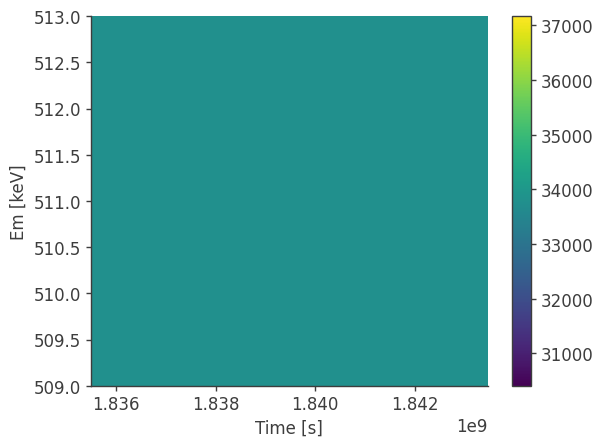

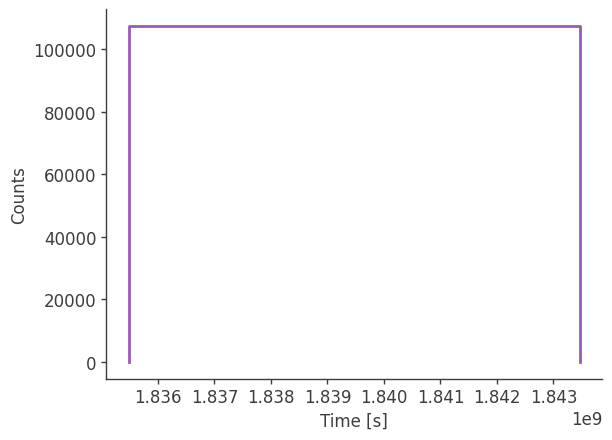

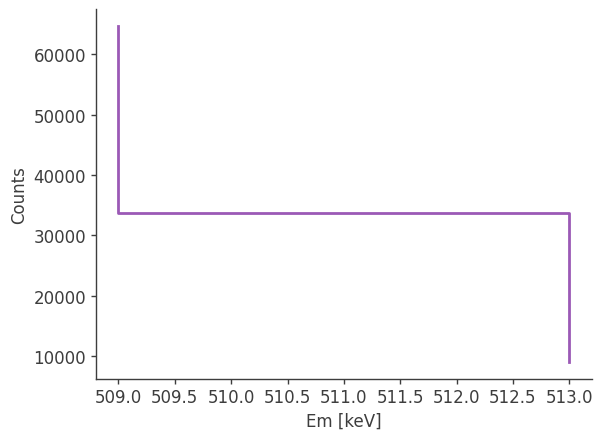

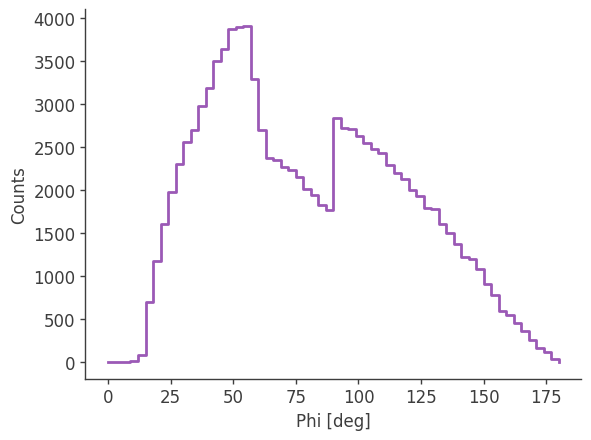

plotting psichi map in galactic...


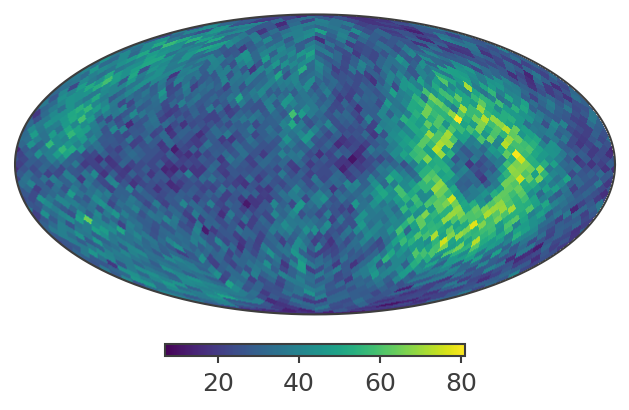

In [2]:
source = BinnedData("input.yml")
source.get_binned_data(unbinned_data="Vela_SNR_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz", make_binning_plots=True, show_plots=1)

In [3]:
bkg = Histogram.open("Total_BG_3months_binned_for_511_filtered_with_SAAcut.hdf5")
bkg.axes.labels


array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [4]:
bkg.axes[0].edges

<Quantity [1.83548730e+09, 1.84346726e+09] s>

In [5]:
event = bkg.to_dense() + source.binned_data.to_dense()

In [6]:
event.write("511kev_event.hdf5", overwrite=True)

In [12]:
event = Histogram.open("511kev_event.hdf5")
ccm = CoordsysConversionMatrix.open("ccm_Fe60_timebinning.hdf5")

In [13]:
data_interface = DataIF_COSI_DC2.load(name="511kev_event.hdf5",
                                        event_binned_data=event ,
                                        dict_bkg_binned_data= {"dict" : bkg},
                                        rsp= FullDetectorResponse.open("Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5"),
                                        coordsys_conv_matrix= ccm,
                                        )

Loading the response matrix onto your computer memory...
Finished
... checking the axis Time of the event and background files...
    --> pass (edges)
... checking the axis Em of the event and background files...
    --> pass (edges)
... checking the axis Phi of the event and background files...
    --> pass (edges)
... checking the axis PsiChi of the event and background files...
    --> pass (edges)
...checking the axis Em of the event and response files...
    --> pass (edges)
...checking the axis Phi of the event and response files...
    --> pass (edges)
...checking the axis PsiChi of the event and response files...
    --> pass (edges)
The axes in the event and background files are redefined. Now they are consistent with those of the response file.
Calculating an exposure map...
Finished...


In [30]:
parameter_filepath = "imagedeconvolution_parfile_scatt_511keV.yml"
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(parameter_filepath)


In [31]:
image_deconvolution.initialize()

#### Initialization Starts ####
<< Instantiating the model class AllSkyImage >>
---- parameters ----
coordinate: galactic
energy_edges:
  unit: keV
  value:
  - 509.0
  - 513.0
nside: 16
scheme: ring
unit: cm-2 s-1 sr-1

<< Setting initial values of the created model object >>
---- parameters ----
algorithm: flat
parameter:
  unit: cm-2 s-1 sr-1
  value:
  - 1e-4

<< Registering the deconvolution algorithm >>
Gaussian filter with FWHM of 2.0 deg will be applied to delta images ...
---- parameters ----
algorithm: RL
parameter:
  acceleration:
    activate: true
    alpha_max: 10.0
  background_normalization_optimization:
    activate: true
    range:
      albedo:
      - 0.01
      - 10.0
  iteration_max: 50
  response_weighting:
    activate: true
    index: 0.5
  save_results:
    activate: false
    directory: ./results
    only_final_result: true
  smoothing: true
  smoothing_FWHM:
    unit: deg
    value: 2.0
  stopping_criteria:
    statistics: log-likelihood
    threshold: 0.01


In [32]:
image_deconvolution.run_deconvolution()

#### Image Deconvolution Starts ####
<< Initialization >>
The response weighting filter was calculated.
The expected count histograms were calculated with the initial model map.


  0%|          | 0/50 [00:00<?, ?it/s]

## Iteration 1/50 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'dict': 0.97966034415616}
  loglikelihood: [3705020.9744273885]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 2/50 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>


...

<< Registering Result >>
  alpha: 1.0
  background_normalization: {'dict': 0.996286364643057}
  loglikelihood: [3705593.3411685745]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 49/50 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'dict': 0.996469377862357}
  loglikelihood: [3705597.681084945]
<< Checking Stopping Criteria >>
--> Continue
## Iteration 50/50 ##
<< Pre-processing >>
<< E-step >>
<< M-step >>
<< Post-processing >>



WARNING RuntimeWarning: invalid value encountered in divide



<< Registering Result >>
  alpha: 1.0
  background_normalization: {'dict': 0.9966485557630207}
  loglikelihood: [3705601.887106645]
<< Checking Stopping Criteria >>
--> Stop
<< Finalization >>
#### Image Deconvolution Finished ####


In [19]:
image_deconvolution.results

[{'iteration': 1,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0bd810>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0bd870>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0bd5d0>,
  'background_normalization': {'dict': 0.97966034415616},
  'alpha': 1.0,
  'loglikelihood': [3705020.9744273885]},
 {'iteration': 2,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0bc5e0>,
  'delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0be080>,
  'processed_delta_model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b0be440>,
  'background_normalization': {'dict': 0.9802430162123329},
  'alpha': 1.0,
  'loglikelihood': [3705049.7171576247]},
 {'iteration': 3,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x71bb7b05cbb0>,
  'delta_model': <cosipy.image_deconvolution.allskyi

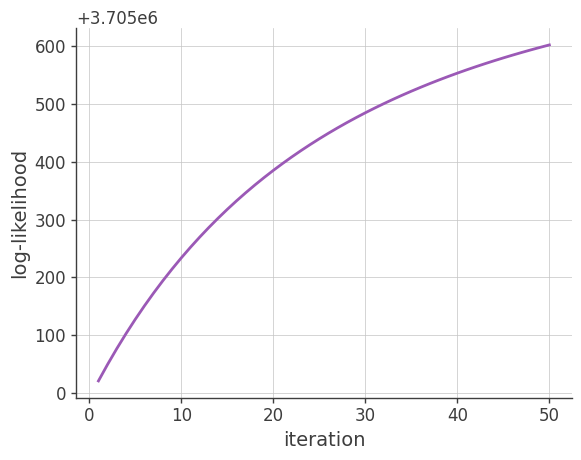

In [33]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['loglikelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

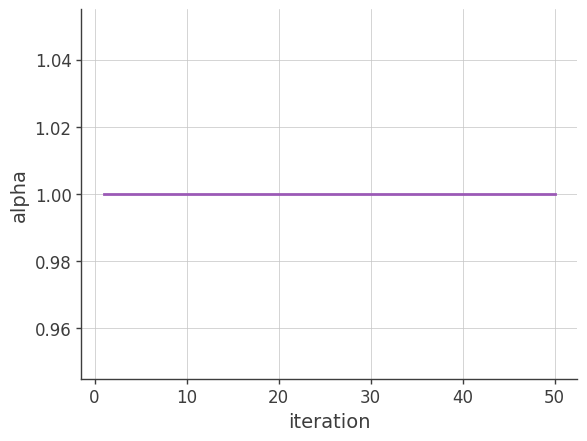

In [34]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("alpha")
plt.show()

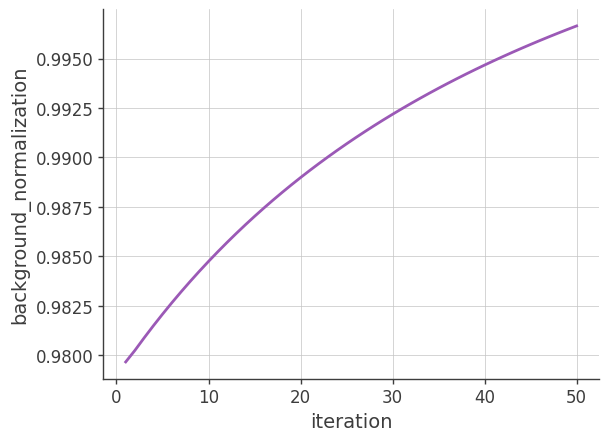

In [35]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['background_normalization']['dict'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("background_normalization")
plt.show()

In [36]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")

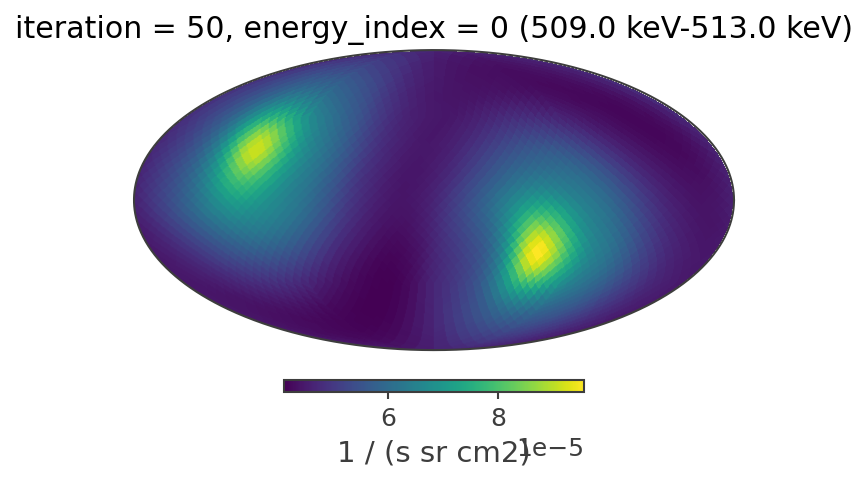

In [37]:
plot_reconstructed_image(image_deconvolution.results[-1])

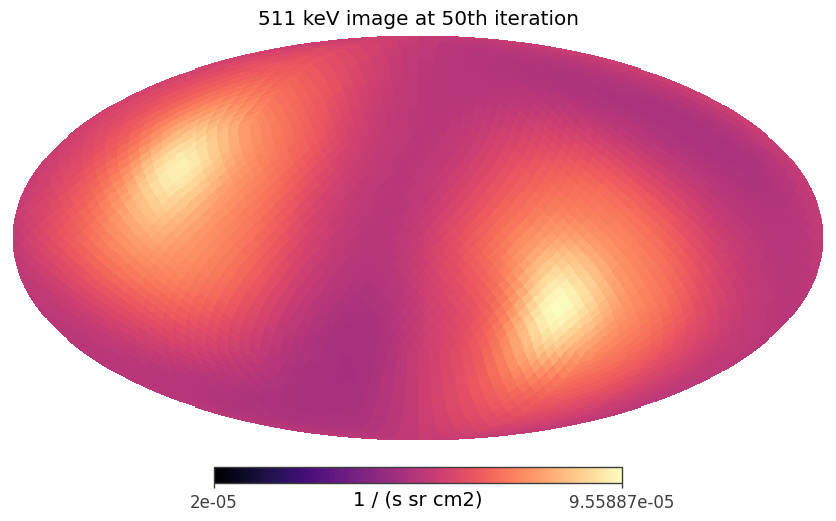

In [38]:
iteration_idx = -1

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

data = image[:,0]
data[data <= 0 * data.unit] = 1e-12 * data.unit

hp.mollview(data, min = 2e-5, norm ='log', unit = str(data.unit), title = f'511 keV image at {iteration}th iteration', cmap = 'magma')

plt.show()